# Spin-symmetry breaking in the uniform electron gas at the Hartree-Fock level

This notebook tests the cleaned-up `my_ueg.py` module and uses it to look at spin-symmetry
breaking in unrestricted Hartree-Fock (UHF) as $r_s$ grows.

1. **Integral check**: the density-fitting-style Coulomb tensor against brute-force 4-index
   integrals, and the RHF energy against the closed-form energy of the plane-wave determinant.
2. **RHF $\to$ UHF (triplet) stability** as a function of $r_s$, and the critical $r_s$.
3. **How the symmetry-broken UHF solution is obtained**, step by step.
4. **$r_s$ scan for $N=14$**: energy lowering, $\langle S^2\rangle$, local moments, and the
   spin-density-wave vector. Includes an independent check of the UHF energy and stationarity.
5. **Spin-density pictures** in real space.
6. **$r_s$ scan for $N=38$**, to see how the picture depends on system size.

All calculations have $M_s = 0$ ($N_\alpha = N_\beta$) and use a plane-wave cutoff
$k_\mathrm{cut} = \gamma k_F$ with $\gamma = 2$.

In [1]:
import time, warnings
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq
from pyscf import lib
import my_ueg

warnings.filterwarnings('ignore', message='Function mol.dumps')
%matplotlib inline

# chart styling: thin 2px lines, recessive grid, text in neutral ink
INK, INK2, GRID = '#0b0b0b', '#52514e', '#e1e0d9'
C1, C2 = '#2a78d6', '#eb6834'      # series slot 1 (N=14), slot 2 (N=38)
plt.rcParams.update({
    'figure.facecolor': '#fcfcfb', 'axes.facecolor': '#fcfcfb', 'axes.edgecolor': INK2,
    'axes.labelcolor': INK, 'xtick.color': INK2, 'ytick.color': INK2, 'text.color': INK,
    'axes.grid': True, 'grid.color': GRID, 'grid.linewidth': 0.8, 'axes.spines.top': False,
    'axes.spines.right': False, 'lines.linewidth': 2, 'lines.markersize': 6, 'font.size': 11,
    'legend.frameon': False})
print('threads:', lib.num_threads())

threads: 16


## 0. Using the module

```python
import my_ueg
mol = my_ueg.M(rs=5.0, nelec=(7, 7), gamma=2.0, verbose=4)   # pyscf Mole, with mol.ueg attached
mf  = my_ueg.RHF(mol)       # or my_ueg.UHF(mol): density-fitted SCF with UEG integrals attached
mf.kernel()

mf_u = my_ueg.run_uhf(mol)  # UHF that follows instabilities down to a stable solution
```

`my_ueg.M` builds an empty `Mole` with `nelectron`, `spin` and `nao` set. `RHF`/`UHF` return
pyscf DF-SCF objects that replace `get_hcore`, `get_ovlp`, `energy_nuc` and `_cderi` with the
UEG quantities. These objects can go straight into post-HF methods, e.g. `cc.RCCSD(mf)`.

The basis is real: $1/\sqrt V$, $\sqrt{2/V}\cos(\mathbf k\cdot\mathbf r)$ and
$\sqrt{2/V}\sin(\mathbf k\cdot\mathbf r)$ for each $\pm\mathbf k$ pair. All integrals are
therefore real, and real-valued UHF orbitals can mix different momenta.

## 1. Integral and RHF checks

* The 3-index tensor gives $(pq|rs) = \sum_g L_{g,pq}L_{g,rs}$. This is compared with the
  brute-force plane-wave integrals
  $\langle k_1k_2|k_3k_4\rangle = \frac{4\pi}{V|k_1-k_3|^2}\delta_{k_1+k_2,k_3+k_4}$
  rotated to the cos/sin basis.
* For a closed shell, the plane-wave determinant is the exact RHF solution. Its energy is
  $E = \sum_{i\sigma} k_i^2/2 - \sum_{i\ne j}^{\rm occ} \frac{4\pi}{V|k_i-k_j|^2} + N v_M/2$.
  This value must not depend on $\gamma$ once the occupied shells are inside the cutoff.

In [2]:
for nocc, rs, gamma in [(7, 1.0, np.sqrt(2)), (7, 5.0, 2.0), (19, 2.0, 1.3)]:
    mol = my_ueg.M(rs=rs, nelec=(nocc, nocc), gamma=gamma, verbose=0)
    ueg = mol.ueg
    L = lib.unpack_tril(ueg.get_cderi_real())
    eri = lib.einsum('gpq,grs->pqrs', L, L)
    u = ueg.pw2real()
    eri_ref = np.einsum('pa,qb,rc,sd,abcd->pqrs', u.conj(), u, u.conj(), u, ueg.get_eris_hard(), optimize=True)

    k = ueg.kpts[:nocc]
    q2 = np.sum((k[:, None] - k[None])**2, -1); np.fill_diagonal(q2, np.inf)
    e_exact = np.sum(k**2) - np.sum(4*np.pi/q2/ueg.volume) + ueg.energy_nuc()
    e_rhf = my_ueg.RHF(mol).kernel()
    print(f'N={2*nocc:3d} rs={rs:3.1f} nk={ueg.nkpts:3d} naux={L.shape[0]:4d} | '
          f'max|eri - eri_ref| = {abs(eri - eri_ref).max():.1e} (imag {abs(eri_ref.imag).max():.1e}) | '
          f'E_RHF = {e_rhf:.10f}  exact = {e_exact:.10f}')

print('\nE_RHF/N at rs = 5, N = 14 for several cutoffs:')
for gamma in [1.2, 1.6, 2.0, 2.5]:
    mol = my_ueg.M(rs=5.0, nelec=(7, 7), gamma=gamma, verbose=0)
    print(f'  gamma = {gamma}: nk = {mol.nao:4d}  E_RHF/N = {my_ueg.RHF(mol).kernel()/14:.12f}')

N= 14 rs=1.0 nk= 19 naux=  92 | max|eri - eri_ref| = 1.4e-17 (imag 0.0e+00) | E_RHF = 8.4914814674  exact = 8.4914814674
N= 14 rs=5.0 nk= 57 naux= 340 | max|eri - eri_ref| = 3.5e-18 (imag 4.3e-19) | E_RHF = -0.8125485303  exact = -0.8125485303
N= 38 rs=2.0 nk= 33 naux= 184 | max|eri - eri_ref| = 6.9e-18 (imag 1.1e-18) | E_RHF = 0.6847559861  exact = 0.6847559861

E_RHF/N at rs = 5, N = 14 for several cutoffs:
  gamma = 1.2: nk =   19  E_RHF/N = -0.058039180734
  gamma = 1.6: nk =   27  E_RHF/N = -0.058039180734
  gamma = 2.0: nk =   57  E_RHF/N = -0.058039180734
  gamma = 2.5: nk =   93  E_RHF/N = -0.058039180734


## 2. RHF $\to$ UHF (triplet) instability

The real RHF $\to$ real UHF orbital Hessian is
$(\mathbf A+\mathbf B)^{T}_{ia,jb} = \delta_{ij}\delta_{ab}(\varepsilon_a-\varepsilon_i) - (ij|ab) - (ib|ja)$.
It is applied with pyscf's Hessian-vector product (`stability._gen_hop_rhf_external`), and its
lowest eigenvalue comes from Davidson (`my_ueg.rhf_triplet_instability`). Once that eigenvalue is
negative, the RHF determinant is a saddle point and a lower-energy UHF solution with broken
$\langle S^2\rangle$ must exist.

For $N=14$ the Hessian is small ($n_{occ}n_{vir} = 350$), so it is also diagonalized exactly as a check.
The instability comes from exchange ($\propto 1/r_s$) outweighing the kinetic-energy gap
($\propto 1/r_s^2$), so it should appear above some critical $r_s$.

In [3]:
from pyscf.scf import stability

def rhf_at(rs, nocc=7, gamma=2.0):
    mol = my_ueg.M(rs=rs, nelec=(nocc, nocc), gamma=gamma, verbose=0)
    mf = my_ueg.RHF(mol); mf.kernel()
    return mol, mf

# exact diagonalization vs Davidson at rs = 4
mol, mf = rhf_at(4.0)
_, _, hop, hdiag = stability._gen_hop_rhf_external(mf, with_symmetry=False)
H = np.array([hop(x) for x in np.eye(hdiag.size)])
print('rs = 4, lowest triplet eigenvalues  exact   :', np.linalg.eigvalsh(0.5*(H + H.T))[:3])
print('rs = 4, lowest triplet eigenvalues  Davidson:', my_ueg.rhf_triplet_instability(mf, nroots=3))

rs_trip = np.array([1, 2, 3, 3.5, 3.8, 4, 4.5, 5, 6, 7, 8, 10, 12, 15, 20])
trip14 = np.array([my_ueg.rhf_triplet_instability(rhf_at(rs)[1], nroots=1)[0] for rs in rs_trip])
rs_c14 = brentq(lambda rs: my_ueg.rhf_triplet_instability(rhf_at(rs)[1], nroots=1)[0], 3.0, 4.0, xtol=1e-4)
print(f'\ncritical rs (N=14, gamma=2): rs_c = {rs_c14:.4f}')
for rs, e in zip(rs_trip, trip14):
    print(f'  rs = {rs:5.1f}   lowest triplet eigenvalue = {e: .6f}   {"UNSTABLE" if e < -1e-6 else "stable"}')

rs = 4, lowest triplet eigenvalues  exact   : [-0.00200457 -0.00200457 -0.00200457]
rs = 4, lowest triplet eigenvalues  Davidson: [-0.00200456 -0.00200455 -0.00200455]

critical rs (N=14, gamma=2): rs_c = 3.9091
  rs =   1.0   lowest triplet eigenvalue =  0.994535   stable
  rs =   2.0   lowest triplet eigenvalue =  0.165510   stable
  rs =   3.0   lowest triplet eigenvalue =  0.035380   stable
  rs =   3.5   lowest triplet eigenvalue =  0.011743   stable
  rs =   3.8   lowest triplet eigenvalue =  0.002662   stable
  rs =   4.0   lowest triplet eigenvalue = -0.002005   UNSTABLE
  rs =   4.5   lowest triplet eigenvalue = -0.010327   UNSTABLE
  rs =   5.0   lowest triplet eigenvalue = -0.015483   UNSTABLE
  rs =   6.0   lowest triplet eigenvalue = -0.020699   UNSTABLE
  rs =   7.0   lowest triplet eigenvalue = -0.022561   UNSTABLE
  rs =   8.0   lowest triplet eigenvalue = -0.022929   UNSTABLE
  rs =  10.0   lowest triplet eigenvalue = -0.021948   UNSTABLE
  rs =  12.0   lowest triplet 

## 3. Getting a self-consistent spin-symmetry-broken UHF solution

**Why plain UHF is not enough.** Start UHF from the plane-wave determinant (or from RHF orbitals).
Then $D^\alpha = D^\beta$, so $F^\alpha = F^\beta$, and each SCF step keeps $D^\alpha = D^\beta$
exactly. The density is also uniform, so the Fock matrix conserves momentum and the orbitals stay
plane waves. The RHF solution is a stationary point of the UHF energy with exactly zero orbital
gradient. DIIS therefore converges in one cycle to $E_\mathrm{UHF} = E_\mathrm{RHF}$ and
$\langle S^2\rangle = 0$, even when this point is a saddle. A broken-symmetry solution in the
UEG is a spin-density wave (Overhauser type). It needs spin symmetry **and** translational
symmetry broken together: $\alpha$ and $\beta$ orbitals must mix different $\mathbf k$ in
opposite ways. The first-order SCF map cannot produce this from a symmetric start.

**What is done here** (`my_ueg.run_uhf`):

1. **Real basis, real orbitals.** The cos/sin basis makes $h$, $L_{g,pq}$ and the UHF orbitals
   real. A real orbital rotation can then build the density modulation
   $m(\mathbf r) \sim \cos(\mathbf Q\cdot\mathbf r)$ that an SDW needs.
2. **Diagnose.** Converge UHF (DIIS, `conv_tol = 1e-9`). Then compute the lowest eigenpair of the
   full UHF orbital Hessian with pyscf's Hessian-vector product `newton_ah.gen_g_hop_uhf` and
   Davidson (`my_ueg.uhf_internal_instability`). At the RHF point this Hessian contains the
   triplet block from Section 2, and its lowest eigenvalue is exactly twice the triplet one
   (pyscf convention; checked below).
   The Davidson guess includes random vectors. At the plane-wave determinant the Hessian is block
   diagonal in the momentum transfer $\mathbf Q$, and random vectors make sure every sector is
   sampled. At these $r_s$, pyscf's stock `mf.stability()` also detects the instability; the random
   vectors are a safeguard.
3. **Follow the instability.** If the lowest eigenvalue is below $-10^{-5}$, rotate the orbitals
   along its eigenvector $\kappa$: $C^\alpha \to C^\alpha e^{\kappa^\alpha}$,
   $C^\beta \to C^\beta e^{\kappa^\beta}$. For the triplet mode $\kappa^\beta = -\kappa^\alpha$,
   so $\alpha$ and $\beta$ densities move in opposite directions. Rebuild $D^\alpha$ and $D^\beta$
   and restart the SCF. The kick is a finite step along a direction of negative curvature, so the
   new SCF runs downhill into the broken-symmetry basin.
4. **Repeat** steps 2-3 until the lowest Hessian eigenvalue is $\ge -10^{-5}$, i.e. the solution
   is a local minimum. Small negative or zero eigenvalues ($\sim10^{-6}$) are expected at the end.
   These are Goldstone modes: moving the SDW rigidly through the box does not change the energy.
5. **Fallback.** If DIIS does not converge, second-order SCF (`mf.newton()`) finishes it.
6. **Several starting points.** At large $r_s$ the UHF energy surface has several local minima
   (different SDW patterns and wavevectors). Each $r_s$ is therefore also started from
   (a) random spin kicks `my_ueg.spin_kick_dm`, with $D^\alpha$ built from $e^{+K}C_\mathrm{occ}$
   and $D^\beta$ from $e^{-K}C_\mathrm{occ}$ for a random antisymmetric $K$, and (b) the best
   solution at the previous $r_s$. Every start goes through the same stability-following loop,
   and the lowest converged, stable result is kept. The scan also records whether solutions differ.

The next cells show each step at $r_s = 5$ for $N = 14$.

In [4]:
rs = 5.0
mol = my_ueg.M(rs=rs, nelec=(7, 7), gamma=2.0, verbose=0)
mf_r = my_ueg.RHF(mol); e_rhf = mf_r.kernel()

# (i) plain UHF from the symmetric guess: stuck at the RHF saddle point
mf_plain = my_ueg.UHF(mol); mf_plain.kernel()
e_hess, _ = my_ueg.uhf_internal_instability(mf_plain, nroots=1)
print(f'plain UHF      : E - E_RHF = {mf_plain.e_tot - e_rhf:.2e}  <S^2> = {mf_plain.spin_square()[0]:.2e}  '
      f'lowest UHF Hessian eig = {e_hess[0]:.5f}')
print(f'2 x lowest triplet eig of RHF = {2*my_ueg.rhf_triplet_instability(mf_r, nroots=1)[0]:.5f}')

# (ii) stability following: the log shows every SCF + stability cycle
print('\nrun_uhf log:')
mf_u = my_ueg.run_uhf(mol, verbose=3)
print(f'\nstable UHF     : (E - E_RHF)/N = {(mf_u.e_tot - e_rhf)/14:.3e}  <S^2> = {mf_u.spin_square()[0]:.4f}  '
      f'converged = {mf_u.converged}  stable = {mf_u.stable}  lowest eig = {mf_u.hessian_eig:.1e}')

plain UHF      : E - E_RHF = -1.11e-16  <S^2> = 8.88e-16  lowest UHF Hessian eig = -0.03097
2 x lowest triplet eig of RHF = -0.03097

run_uhf log:
converged SCF energy = -0.81254853028218  <S^2> = -8.8817842e-16  2S+1 = 1
stability cycle 0  E = -0.8125485303  lowest Hessian eig = -3.097e-02


Overwritten attributes  get_ovlp get_hcore get_init_guess energy_nuc  of <class 'pyscf.df.df_jk.DFUHF'>


converged SCF energy = -0.823662827511488  <S^2> = 2.5207015  2S+1 = 3.3290849
stability cycle 1  E = -0.8236628275  lowest Hessian eig = -4.631e-07

stable UHF     : (E - E_RHF)/N = -7.939e-04  <S^2> = 2.5207  converged = True  stable = True  lowest eig = -4.6e-07


In [5]:
# (iii) several starting points at rs = 10: the UHF surface has more than one local minimum
mol = my_ueg.M(rs=10.0, nelec=(7, 7), gamma=2.0, verbose=0)
e_rhf10 = my_ueg.RHF(mol).kernel()
for label, dm0 in [('from RHF + stability', None)] + [(f'spin kick seed {s}', my_ueg.spin_kick_dm(mol, 0.1, seed=s)) for s in range(4)]:
    m = my_ueg.run_uhf(mol, dm0=dm0, verbose=0)
    print(f'{label:22s}: (E_UHF - E_RHF)/N = {(m.e_tot - e_rhf10)/14: .7f}  <S^2> = {m.spin_square()[0]:.4f}  stable = {m.stable}')

from RHF + stability  : (E_UHF - E_RHF)/N = -0.0033949  <S^2> = 5.6583  stable = True
spin kick seed 0      : (E_UHF - E_RHF)/N = -0.0039860  <S^2> = 6.1378  stable = True
spin kick seed 1      : (E_UHF - E_RHF)/N = -0.0033949  <S^2> = 5.6583  stable = True
spin kick seed 2      : (E_UHF - E_RHF)/N = -0.0039861  <S^2> = 6.1405  stable = True
spin kick seed 3      : (E_UHF - E_RHF)/N = -0.0039861  <S^2> = 6.1398  stable = True


## 4. $r_s$ scan for $N = 14$

For each $r_s$:
* RHF energy and lowest triplet eigenvalue;
* best stable UHF from: stability following from RHF, 6 random spin kicks, and the previous $r_s$ solution;
* $\langle S^2\rangle$; the local moment $\frac1N\int|m(\mathbf r)|\,d\mathbf r$ with $m=\rho_\alpha-\rho_\beta$;
  the relative charge-density modulation $\sigma(\rho)/\bar\rho$; and the dominant Fourier
  component $|\mathbf Q|/k_F$ of $m(\mathbf r)$.

In [6]:
def density_analysis(mol, dm, ngrid=24):
    ueg = mol.ueg
    _, rho, m = my_ueg.spin_density(mol, dm, ngrid)
    moment = np.mean(np.abs(m)) * ueg.volume / mol.nelectron
    charge_mod = rho.std() / rho.mean()
    mk = np.abs(np.fft.fftn(m.reshape((ngrid,)*3)))
    mk[0, 0, 0] = 0
    idx = np.array(np.unravel_index(np.argmax(mk), mk.shape))
    n = np.where(idx <= ngrid//2, idx, idx - ngrid)
    kf = (2*np.pi/ueg.length) * (3*mol.nelectron/(8*np.pi))**(1/3)
    Q = np.linalg.norm(n) * 2*np.pi/ueg.length / kf if moment > 1e-4 else np.nan
    return moment, charge_mod, Q

def best_uhf(mol, extra_dm=(), nkick=6, amp=0.1):
    starts = [('rhf', None)] + [(f'kick{s}', my_ueg.spin_kick_dm(mol, amp, seed=s)) for s in range(nkick)]
    starts += [('prev', d) for d in extra_dm]
    runs = []
    for label, dm0 in starts:
        m = my_ueg.run_uhf(mol, dm0=dm0, verbose=0)
        runs.append((m.e_tot, label, m))
    good = [r for r in runs if r[2].converged and r[2].stable]
    e, label, m = min(good or runs, key=lambda r: r[0])
    return m, label, np.array([r[0] for r in runs])

def scan(nocc, rs_list, gamma=2.0, nkick=6):
    rows, prev_dm = [], None
    N = 2*nocc
    for rs in rs_list:
        t0 = time.time()
        mol = my_ueg.M(rs=rs, nelec=(nocc, nocc), gamma=gamma, verbose=0)
        mf_r = my_ueg.RHF(mol); e_r = mf_r.kernel()
        trip = my_ueg.rhf_triplet_instability(mf_r, nroots=1)[0]
        mf_u, label, e_all = best_uhf(mol, extra_dm=() if prev_dm is None else (prev_dm,), nkick=nkick)
        prev_dm = mf_u.make_rdm1()
        moment, cmod, Q = density_analysis(mol, prev_dm)
        row = dict(rs=rs, e_rhf=e_r/N, e_uhf=mf_u.e_tot/N, de=(mf_u.e_tot - e_r)/N, trip=trip,
                   s2=mf_u.spin_square()[0], moment=moment, cmod=cmod, Q=Q, conv=mf_u.converged,
                   stable=mf_u.stable, heig=mf_u.hessian_eig, best=label,
                   nminima=len(np.unique(np.round(e_all/N, 6))), dm=prev_dm)
        rows.append(row)
        print(f"rs {rs:5.2f} | E_RHF/N {row['e_rhf']: .7f} E_UHF/N {row['e_uhf']: .7f} dE/N {row['de']: .2e} | "
              f"trip {trip: .4f} | <S2> {row['s2']:.3f} moment {moment:.3f} dRho {cmod:.3f} |Q|/kF {Q:.2f} | "
              f"conv {row['conv']} stable {row['stable']} eig {row['heig']: .1e} best={label} "
              f"#distinct E {row['nminima']} | {time.time()-t0:.0f}s", flush=True)
    return rows

rs_list14 = [1, 2, 3, 3.5, 3.8, 3.95, 4.0, 4.1, 4.3, 4.5, 5, 6, 7, 8, 10, 12, 15, 20]
res14 = scan(7, rs_list14)

rs  1.00 | E_RHF/N  0.6065344 E_UHF/N  0.6065344 dE/N  2.54e-16 | trip  0.9945 | <S2> -0.000 moment 0.000 dRho 0.000 |Q|/kF nan | conv True stable True eig  2.0e+00 best=rhf #distinct E 1 | 1s
rs  2.00 | E_RHF/N  0.0230390 E_UHF/N  0.0230390 dE/N  0.00e+00 | trip  0.1655 | <S2> 0.000 moment 0.000 dRho 0.000 |Q|/kF nan | conv True stable True eig  3.3e-01 best=rhf #distinct E 1 | 1s
rs  3.00 | E_RHF/N -0.0469136 E_UHF/N -0.0469136 dE/N  1.59e-17 | trip  0.0354 | <S2> -0.000 moment 0.000 dRho 0.000 |Q|/kF nan | conv True stable True eig  7.1e-02 best=prev #distinct E 1 | 1s
rs  3.50 | E_RHF/N -0.0554622 E_UHF/N -0.0554622 dE/N -2.38e-17 | trip  0.0117 | <S2> 0.000 moment 0.000 dRho 0.000 |Q|/kF nan | conv True stable True eig  2.3e-02 best=prev #distinct E 1 | 1s
rs  3.80 | E_RHF/N -0.0577372 E_UHF/N -0.0577372 dE/N -2.38e-17 | trip  0.0027 | <S2> 0.000 moment 0.000 dRho 0.000 |Q|/kF nan | conv True stable True eig  5.3e-03 best=rhf #distinct E 1 | 2s
rs  3.95 | E_RHF/N -0.0583805 E_UHF/

### Consistency checks on the scan

* Below $r_s^c$ (triplet eigenvalue $>0$) the stable UHF has to coincide with RHF:
  $\Delta E = 0$, $\langle S^2\rangle = 0$.
* Above $r_s^c$ the stable UHF must lie strictly below RHF, and symmetry breaking in the SCF
  should begin where the independently computed triplet eigenvalue crosses zero.
* Every kept solution must be converged and stable.

In [7]:
r = {k: np.array([row[k] for row in res14]) for k in ['rs', 'de', 'trip', 's2', 'moment', 'cmod', 'Q', 'conv', 'stable']}
below, above = r['rs'] < rs_c14, r['rs'] > rs_c14
print(f"rs_c(triplet) = {rs_c14:.4f}")
print("below rs_c: max |dE/N|   =", np.abs(r['de'][below]).max(), "  max <S^2> =", r['s2'][below].max())
print("above rs_c: max dE/N     =", r['de'][above].max(), "  (must be < 0)")
print("all converged:", r['conv'].all(), "  all stable:", r['stable'].all())
print("largest rs with dE/N > -1e-8:", r['rs'][r['de'] > -1e-8].max(),
      " smallest rs with dE/N < -1e-8:", r['rs'][r['de'] < -1e-8].min())

rs_c(triplet) = 3.9091
below rs_c: max |dE/N|   = 2.5376526277146434e-16   max <S^2> = 3.552713678800501e-15
above rs_c: max dE/N     = -2.1999203585159373e-06   (must be < 0)
all converged: True   all stable: True
largest rs with dE/N > -1e-8: 3.8  smallest rs with dE/N < -1e-8: 3.95


### Independent check of one symmetry-broken solution

For the $r_s = 10$ solution, the UHF energy and the SCF stationarity conditions
$[F^\sigma, D^\sigma] = 0$ are recomputed from **brute-force 4-index integrals** (not the
3-index tensor used in the SCF). This tests the DF UHF energy and the self-consistency.

In [8]:
row = [row for row in res14 if row['rs'] == 10][0]
mol = my_ueg.M(rs=10.0, nelec=(7, 7), gamma=2.0, verbose=0)
ueg = mol.ueg
u = ueg.pw2real()
eri = np.einsum('pa,qb,rc,sd,abcd->pqrs', u.conj(), u, u.conj(), u, ueg.get_eris_hard(), optimize=True).real
h1 = ueg.get_h1_real()
da, db = row['dm']
J = np.einsum('pqrs,rs->pq', eri, da + db)
Ka, Kb = np.einsum('prsq,rs->pq', eri, da), np.einsum('prsq,rs->pq', eri, db)
fa, fb = h1 + J - Ka, h1 + J - Kb
e_ref = np.sum(h1*(da + db)) + 0.5*np.sum((J - Ka)*da + (J - Kb)*db) + ueg.energy_nuc()
print(f'E_UHF from SCF     = {row["e_uhf"]*14:.10f}')
print(f'E_UHF brute force  = {e_ref:.10f}')
print(f'||[F_a, D_a]|| = {np.linalg.norm(fa@da - da@fa):.1e}   ||[F_b, D_b]|| = {np.linalg.norm(fb@db - db@fb):.1e}')
print(f'Tr D_a = {np.trace(da):.8f}  Tr D_b = {np.trace(db):.8f}  ||D_a^2 - D_a|| = {np.linalg.norm(da@da - da):.1e}')

E_UHF from SCF     = -0.6190069174
E_UHF brute force  = -0.6190069174
||[F_a, D_a]|| = 1.8e-06   ||[F_b, D_b]|| = 1.7e-06
Tr D_a = 7.00000000  Tr D_b = 7.00000000  ||D_a^2 - D_a|| = 2.7e-15


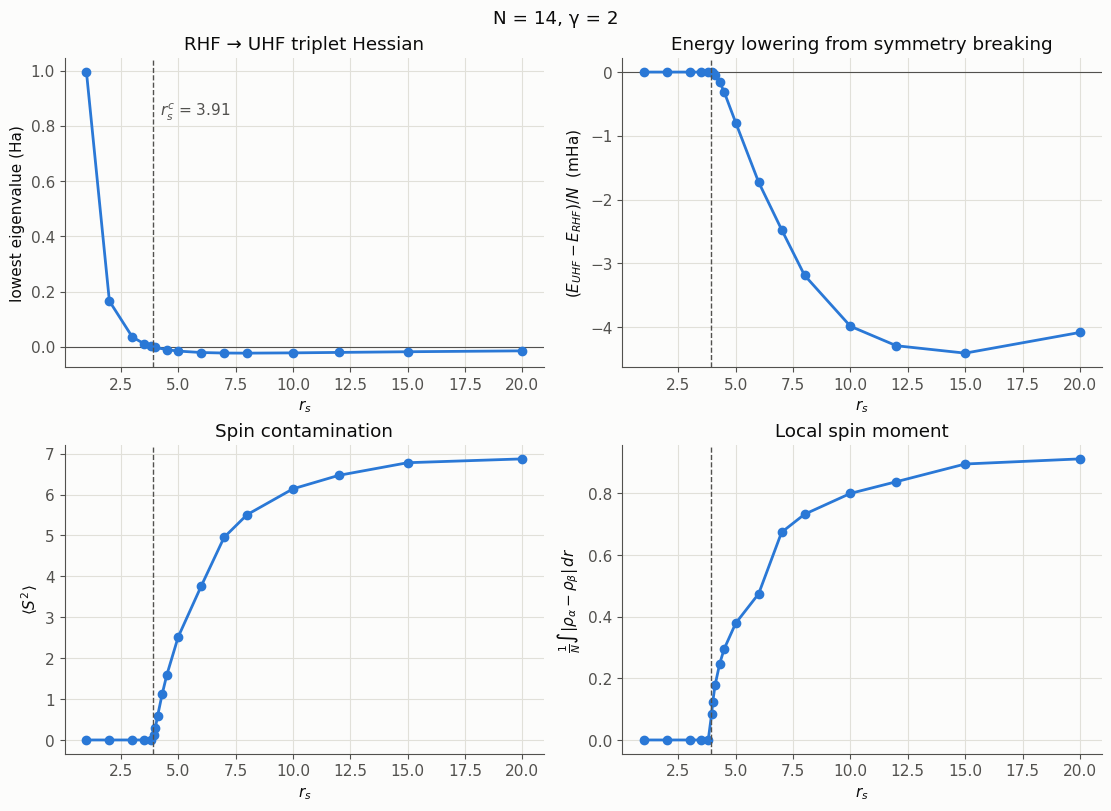

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8), constrained_layout=True)
rs_arr = r['rs']

ax = axes[0, 0]
ax.axhline(0, color=INK2, lw=0.8)
ax.plot(rs_trip, trip14, '-o', color=C1)
ax.axvline(rs_c14, color=INK2, ls='--', lw=1)
ax.text(rs_c14 + 0.3, ax.get_ylim()[1]*0.8, f'$r_s^c$ = {rs_c14:.2f}', color=INK2)
ax.set(xlabel='$r_s$', ylabel='lowest eigenvalue (Ha)', title='RHF → UHF triplet Hessian')

ax = axes[0, 1]
ax.axhline(0, color=INK2, lw=0.8)
ax.plot(rs_arr, r['de']*1e3, '-o', color=C1)
ax.axvline(rs_c14, color=INK2, ls='--', lw=1)
ax.set(xlabel='$r_s$', ylabel='$(E_{UHF}-E_{RHF})/N$  (mHa)', title='Energy lowering from symmetry breaking')

ax = axes[1, 0]
ax.plot(rs_arr, r['s2'], '-o', color=C1)
ax.axvline(rs_c14, color=INK2, ls='--', lw=1)
ax.set(xlabel='$r_s$', ylabel=r'$\langle S^2\rangle$', title='Spin contamination')

ax = axes[1, 1]
ax.plot(rs_arr, r['moment'], '-o', color=C1)
ax.axvline(rs_c14, color=INK2, ls='--', lw=1)
ax.set(xlabel='$r_s$', ylabel=r'$\frac{1}{N}\int |\rho_\alpha-\rho_\beta|\,dr$', title='Local spin moment')
fig.suptitle('N = 14, γ = 2', color=INK)
plt.show()

### Behaviour just above $r_s^c$

In Landau mean-field theory for a continuous transition,
$E(m) \approx a(r_s^c - r_s)m^2 + b m^4$. This gives $\Delta E \propto -(r_s - r_s^c)^2$ and
$m \propto (r_s - r_s^c)^{1/2}$. The log-log slopes from a few $r_s$ values just above
$r_s^c$ test whether the onset of symmetry breaking in the SCF agrees with the triplet
eigenvalue. A clean power law requires this agreement.

rs  3.92 | E_RHF/N -0.0582700 E_UHF/N -0.0582701 dE/N -1.35e-07 | trip -0.0002 | <S2> 0.033 moment 0.042 dRho 0.001 |Q|/kF 1.46 | conv True stable True eig -1.7e-07 best=kick1 #distinct E 1 | 8s
rs  3.93 | E_RHF/N -0.0583070 E_UHF/N -0.0583075 dE/N -5.35e-07 | trip -0.0005 | <S2> 0.066 moment 0.059 dRho 0.001 |Q|/kF 1.46 | conv True stable True eig  1.3e-05 best=prev #distinct E 1 | 3s
rs  3.96 | E_RHF/N -0.0584111 E_UHF/N -0.0584144 dE/N -3.27e-06 | trip -0.0011 | <S2> 0.161 moment 0.093 dRho 0.003 |Q|/kF 1.46 | conv True stable True eig  1.5e-06 best=prev #distinct E 1 | 4s
rs  4.01 | E_RHF/N -0.0585634 E_UHF/N -0.0585760 dE/N -1.26e-05 | trip -0.0022 | <S2> 0.317 moment 0.130 dRho 0.006 |Q|/kF 1.46 | conv True stable True eig -1.6e-06 best=prev #distinct E 2 | 3s
rs  4.11 | E_RHF/N -0.0587941 E_UHF/N -0.0588410 dE/N -4.69e-05 | trip -0.0042 | <S2> 0.612 moment 0.182 dRho 0.012 |Q|/kF 1.46 | conv True stable True eig  2.4e-08 best=prev #distinct E 2 | 2s

log-log slope: dE vs (rs - r

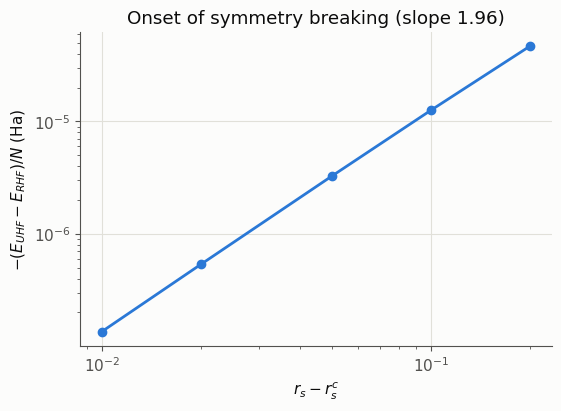

In [10]:
drs = np.array([0.01, 0.02, 0.05, 0.1, 0.2])
near = scan(7, rs_c14 + drs, nkick=3)
de_near = np.array([row['de'] for row in near]); mom_near = np.array([row['moment'] for row in near])
ok = de_near < -1e-12
p_e = np.polyfit(np.log(drs[ok]), np.log(-de_near[ok]), 1)[0]
p_m = np.polyfit(np.log(drs[ok]), np.log(mom_near[ok]), 1)[0]
print(f'\nlog-log slope: dE vs (rs - rs_c): {p_e:.2f} (Landau: 2)   moment vs (rs - rs_c): {p_m:.2f} (Landau: 0.5)')

fig, ax = plt.subplots(figsize=(5.5, 4), constrained_layout=True)
ax.loglog(drs[ok], -de_near[ok], '-o', color=C1)
ax.set(xlabel=r'$r_s - r_s^c$', ylabel=r'$-(E_{UHF}-E_{RHF})/N$ (Ha)', title=f'Onset of symmetry breaking (slope {p_e:.2f})')
plt.show()

## 5. What the broken-symmetry state looks like

Spin density $m(\mathbf r) = \rho_\alpha - \rho_\beta$ and charge density $\rho(\mathbf r)/\bar\rho$
on the plane of the box that contains the largest $|m|$, for several $r_s$ (best solutions from
the $N=14$ scan). The colour scale of $m$ is diverging and centred on zero.

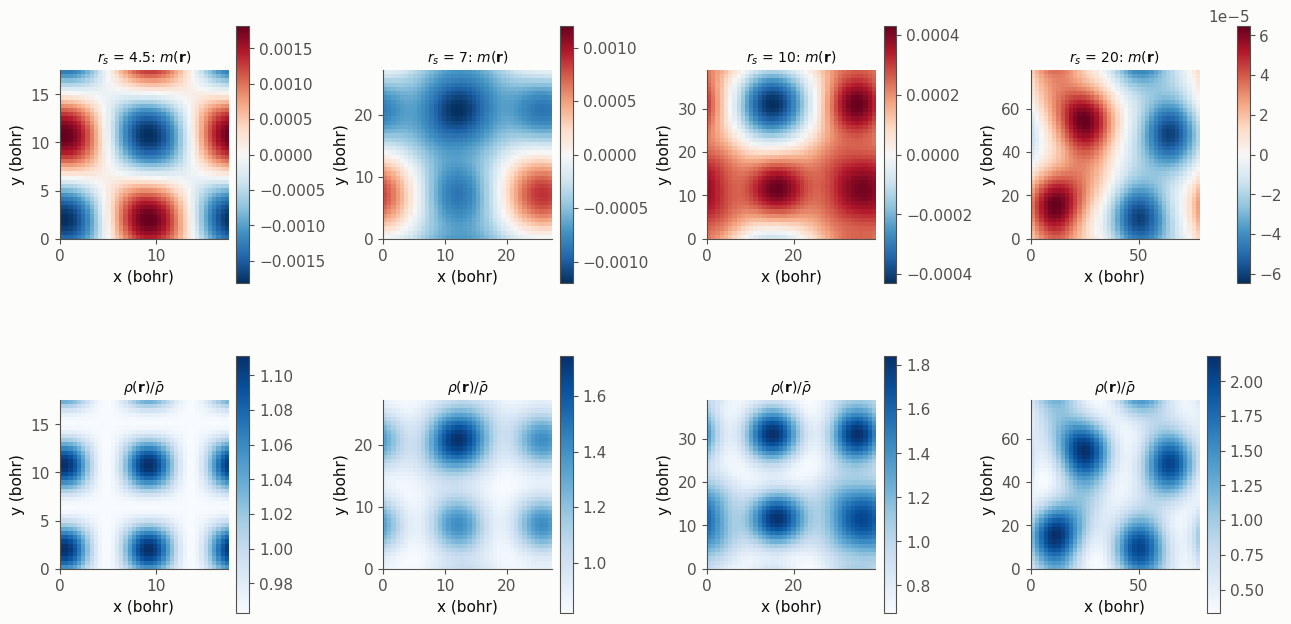

In [11]:
show_rs = [4.5, 7, 10, 20]
ng = 40
fig, axes = plt.subplots(2, len(show_rs), figsize=(3.2*len(show_rs), 6.6), constrained_layout=True)
for j, rs in enumerate(show_rs):
    row = [row for row in res14 if row['rs'] == rs][0]
    mol = my_ueg.M(rs=rs, nelec=(7, 7), gamma=2.0, verbose=0)
    _, rho, m = my_ueg.spin_density(mol, row['dm'], ng)
    m3, rho3 = m.reshape((ng,)*3), rho.reshape((ng,)*3)
    iz = np.unravel_index(np.argmax(np.abs(m3)), m3.shape)[2]
    ext = [0, mol.ueg.length, 0, mol.ueg.length]
    vmax = np.abs(m3).max()
    im = axes[0, j].imshow(m3[:, :, iz].T, origin='lower', extent=ext, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
    axes[0, j].set_title(f'$r_s$ = {rs}: $m(\\mathbf{{r}})$', fontsize=10)
    fig.colorbar(im, ax=axes[0, j], shrink=0.8)
    im = axes[1, j].imshow(rho3[:, :, iz].T/rho.mean(), origin='lower', extent=ext, cmap='Blues')
    axes[1, j].set_title(r'$\rho(\mathbf{r})/\bar\rho$', fontsize=10)
    fig.colorbar(im, ax=axes[1, j], shrink=0.8)
    for ax in axes[:, j]:
        ax.grid(False); ax.set_xlabel('x (bohr)'); ax.set_ylabel('y (bohr)')
plt.show()

## 6. $r_s$ scan for $N = 38$ ($\gamma = 2$, 147 orbitals)

Fewer $r_s$ points and random kicks than for $N=14$, because each UHF run is more expensive.

In [12]:
def rs_c_for(nocc, lo, hi, gamma=2.0):
    f = lambda rs: my_ueg.rhf_triplet_instability(rhf_at(rs, nocc, gamma)[1], nroots=1)[0]
    return brentq(f, lo, hi, xtol=1e-3)

rs_c38 = rs_c_for(19, 3.0, 5.0)
print(f'critical rs (N=38, gamma=2): rs_c = {rs_c38:.3f}\n')
rs_list38 = [2, 3, 4, 5, 6, 8, 10, 15]
res38 = scan(19, rs_list38, nkick=2)

critical rs (N=38, gamma=2): rs_c = 4.019

rs  2.00 | E_RHF/N  0.0180199 E_UHF/N  0.0180199 dE/N  0.00e+00 | trip  0.0947 | <S2> -0.000 moment 0.000 dRho 0.000 |Q|/kF nan | conv True stable True eig  1.9e-01 best=rhf #distinct E 1 | 12s
rs  3.00 | E_RHF/N -0.0469403 E_UHF/N -0.0469403 dE/N -1.17e-17 | trip  0.0232 | <S2> 0.000 moment 0.000 dRho 0.000 |Q|/kF nan | conv True stable True eig  4.6e-02 best=prev #distinct E 1 | 18s
rs  4.00 | E_RHF/N -0.0573128 E_UHF/N -0.0573128 dE/N -1.17e-17 | trip  0.0003 | <S2> 0.000 moment 0.000 dRho 0.000 |Q|/kF nan | conv True stable True eig  5.4e-04 best=rhf #distinct E 1 | 25s
rs  5.00 | E_RHF/N -0.0564619 E_UHF/N -0.0569067 dE/N -4.45e-04 | trip -0.0095 | <S2> 5.572 moment 0.309 dRho 0.060 |Q|/kF 1.35 | conv True stable True eig -8.0e-07 best=kick1 #distinct E 2 | 230s
rs  6.00 | E_RHF/N -0.0529469 E_UHF/N -0.0541134 dE/N -1.17e-03 | trip -0.0137 | <S2> 8.660 moment 0.466 dRho 0.074 |Q|/kF 0.60 | conv True stable True eig  3.8e-06 best=kick0 #di

N=38 all converged: True  all stable: True  max dE/N below rs_c: 1.1686558153949016e-17  max dE/N above rs_c: -0.0004448320665218643


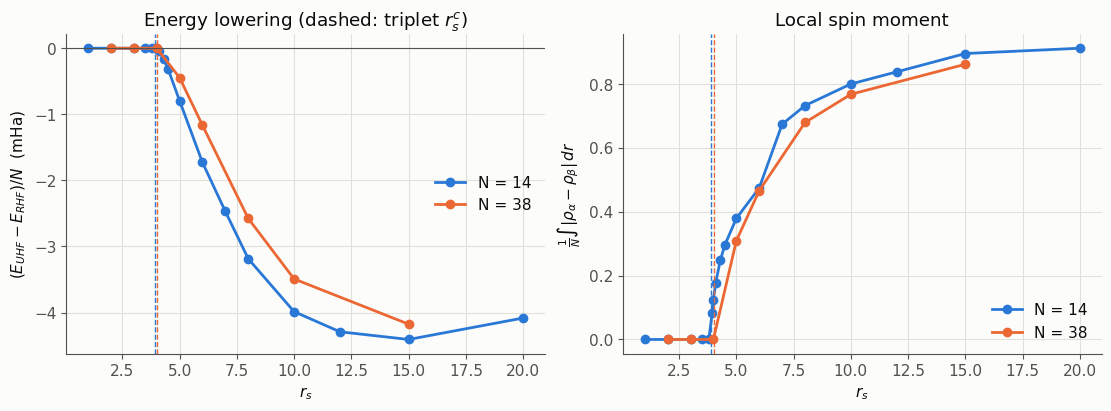

In [13]:
r38 = {k: np.array([row[k] for row in res38]) for k in ['rs', 'de', 's2', 'moment', 'conv', 'stable', 'Q']}
print('N=38 all converged:', r38['conv'].all(), ' all stable:', r38['stable'].all(),
      ' max dE/N below rs_c:', np.abs(r38['de'][r38['rs'] < rs_c38]).max(),
      ' max dE/N above rs_c:', r38['de'][r38['rs'] > rs_c38].max())

fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
for res, rc, col, lab in [(r, rs_c14, C1, 'N = 14'), (r38, rs_c38, C2, 'N = 38')]:
    axes[0].plot(res['rs'], res['de']*1e3, '-o', color=col, label=lab)
    axes[1].plot(res['rs'], res['moment'], '-o', color=col, label=lab)
    for ax in axes:
        ax.axvline(rc, color=col, ls='--', lw=1)
axes[0].axhline(0, color=INK2, lw=0.8)
axes[0].set(xlabel='$r_s$', ylabel='$(E_{UHF}-E_{RHF})/N$  (mHa)', title='Energy lowering (dashed: triplet $r_s^c$)')
axes[1].set(xlabel='$r_s$', ylabel=r'$\frac{1}{N}\int |\rho_\alpha-\rho_\beta|\,dr$', title='Local spin moment')
for ax, (x, y1, y2) in zip(axes, [(r['rs'][-1], r['de'][-1]*1e3, None), (r['rs'][-1], r['moment'][-1], None)]):
    ax.legend(loc='best')
plt.show()

In [14]:
print(f"{'':6s}{'rs':>6s} {'E_RHF/N':>12s} {'E_UHF/N':>12s} {'dE/N':>10s} {'<S2>':>7s} {'moment':>7s} {'dRho':>6s} {'|Q|/kF':>7s}")
for N, res in [(14, res14), (38, res38)]:
    for row in res:
        print(f"N={N:<4d}{row['rs']:6.2f} {row['e_rhf']:12.7f} {row['e_uhf']:12.7f} {row['de']:10.2e} "
              f"{row['s2']:7.3f} {row['moment']:7.3f} {row['cmod']:6.3f} {row['Q']:7.2f}")

          rs      E_RHF/N      E_UHF/N       dE/N    <S2>  moment   dRho  |Q|/kF
N=14    1.00    0.6065344    0.6065344   2.54e-16  -0.000   0.000  0.000     nan
N=14    2.00    0.0230390    0.0230390   0.00e+00   0.000   0.000  0.000     nan
N=14    3.00   -0.0469136   -0.0469136   1.59e-17  -0.000   0.000  0.000     nan
N=14    3.50   -0.0554622   -0.0554622  -2.38e-17   0.000   0.000  0.000     nan
N=14    3.80   -0.0577372   -0.0577372  -2.38e-17   0.000   0.000  0.000     nan
N=14    3.95   -0.0583805   -0.0583827  -2.20e-06   0.133   0.084  0.002    1.46
N=14    4.00   -0.0585376   -0.0585480  -1.05e-05   0.289   0.124  0.005    1.46
N=14    4.10   -0.0587769   -0.0588199  -4.30e-05   0.585   0.178  0.011    1.46
N=14    4.30   -0.0590002   -0.0591576  -1.57e-04   1.119   0.247  0.022    1.46
N=14    4.50   -0.0589526   -0.0592680  -3.15e-04   1.585   0.296  0.032    1.46
N=14    5.00   -0.0580392   -0.0588331  -7.94e-04   2.521   0.379  0.055    1.46
N=14    6.00   -0.0545933   

## Summary

**Implementation checks**
* The 3-index Coulomb tensor matches brute-force 4-index integrals to $10^{-17}$. RHF equals the closed-form energy of the plane-wave determinant and does not change with the cutoff $\gamma$.
* The Davidson triplet eigenvalues match exact diagonalization. At the RHF point, the lowest UHF Hessian eigenvalue is exactly twice the triplet eigenvalue.
* For the $r_s=10$ broken-symmetry solution, recomputing with brute-force integrals reproduces $E_\mathrm{UHF}$ to $10^{-10}$ Ha, with $\|[F^\sigma,D^\sigma]\|\sim10^{-6}$ and idempotent densities that have the correct traces.

**Spin-symmetry breaking** ($M_s=0$, $\gamma=2$)

| | $r_s^c$ (triplet Hessian) | first $r_s$ with $E_\mathrm{UHF}<E_\mathrm{RHF}$ in the scan |
|---|---|---|
| $N=14$ | 3.909 | 3.92 ($r_s^c+0.01$) |
| $N=38$ | 4.019 | 5 (grid: 4, 5) |

* Below $r_s^c$, every start (stability following and random kicks) returns to RHF: $\Delta E=0$ and $\langle S^2\rangle=0$ to machine precision. Above $r_s^c$, a lower, stable UHF solution always exists.
* Near $r_s^c$ the SCF gives $\Delta E\propto(r_s-r_s^c)^{1.96}$ and moment $\propto(r_s-r_s^c)^{0.49}$, the mean-field exponents 2 and 1/2 of a continuous transition. So the SCF symmetry breaking starts exactly where the independently computed triplet eigenvalue crosses zero.
* **Just above $r_s^c$:** a weak spin-density wave with little charge modulation ($\sigma_\rho/\bar\rho\lesssim5\%$).
* **With growing $r_s$:** the local moment rises toward 1 (0.91 at $r_s=20$ for $N=14$) and $\langle S^2\rangle$ grows (6.9 for $N=14$, 18.3 at $r_s=15$ for $N=38$).
* **At large $r_s$:** the charge density becomes strongly modulated (peaks at 2$\times\bar\rho$), like an antiferromagnetic Wigner crystal.
* The dominant wavevector of $m(\mathbf r)$ jumps from $|\mathbf Q|/k_F=1.46$ to $0.84$ between $r_s=6$ and 7 for $N=14$, and from 1.35 to 0.60 between 5 and 6 for $N=38$. These are pattern changes between different local minima. The allowed $|\mathbf Q|$ are discrete box vectors, so the values are finite-size specific.

**Caveats**
* Only real, $M_s=0$ UHF is explored. Ferromagnetic states (different $M_s$), GHF and complex solutions are not included.
* The search for the global UHF minimum is not exhaustive. At large $r_s$ up to four distinct stable minima were found among the starts, and $N=38$ used only 3-4 starts per $r_s$. The reported $E_\mathrm{UHF}$ is therefore an upper bound on the lowest UHF energy.
* $(E_\mathrm{UHF}-E_\mathrm{RHF})/N$ in Hartree flattens and turns around at large $r_s$ because all energies shrink like $1/r_s$. The moment and $\langle S^2\rangle$ keep growing.
